In [1]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds


ids =[35,34]#小鼠大脑局部RNA

adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
#adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train stMSA
adatas = train_integration(adata=adatas, radius=2)

# calculate the clustering result
#adata = stds.cl.evaluate_embedding(adatas,6)# len(set(adatas.obs['cluster']))-1)
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=9)
# other downstream tasks

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151786RNA, size: (9215, 18107), cluster: 6.(5.330s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151785RNA, size: (2372, 18107), cluster: 6.(1.203s)
[AnnData object with n_obs × n_vars = 9215 × 18107
    obs: 'src'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 2372 × 18107
    obs: 'src'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial']
AnnData object with n_obs × n_vars = 11587 × 18107
    obs: 'src', 'batch'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 11587 × 18107
    obs: 'src', 'batch'
    obsm: 'spatial'
3
[[   0 8180]
 [   0    0]
 [   0   82]
 ...
 [9214 7250]
 [9214 8259]
 [9214 8258]]
>>> INFO: Generate 1178

  0%|          | 0/200 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 119678 mnn node pairs(0.538s)!


 50%|█████     | 100/200 [09:18<09:13,  5.53s/it]

>>> INFO: Finish finding mmn pairs, find 160764 mnn node pairs(0.418s)!


100%|██████████| 200/200 [18:56<00:00,  5.68s/it]
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [3]:
adata.write('mousebrain_P2122RNA.h5ad', compression='gzip')

In [18]:
import scanpy as sc
adata=sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P2122RNA.h5ad')

In [19]:
adata1 = adata[adata.obs['batch'] == '0']

In [20]:
adata2 = adata[adata.obs['batch'] == '1']

In [ ]:
import scanpy as sc
import pandas as pd


adata = sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P2122RNA.h5ad')
adata.X[1,]
#

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

d:\Anaconda\envs\cast\lib\site-packages\scanpy\preprocessing\_simple.py:373: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_dotplot.py:169: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_dotplot.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_dotplot.py:749: UserWarning: No data for

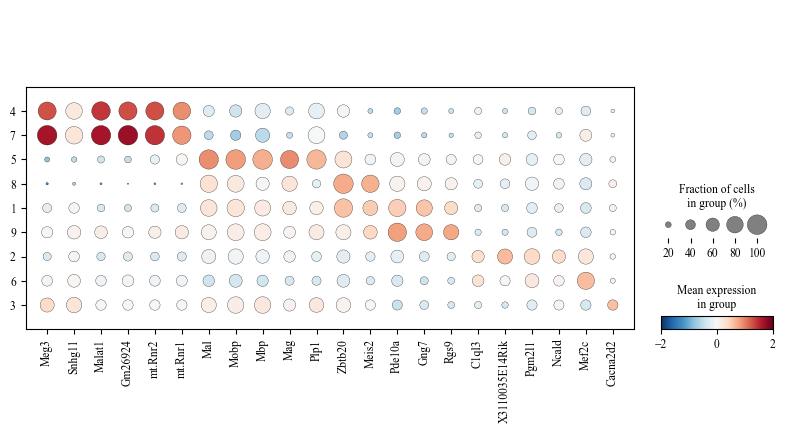

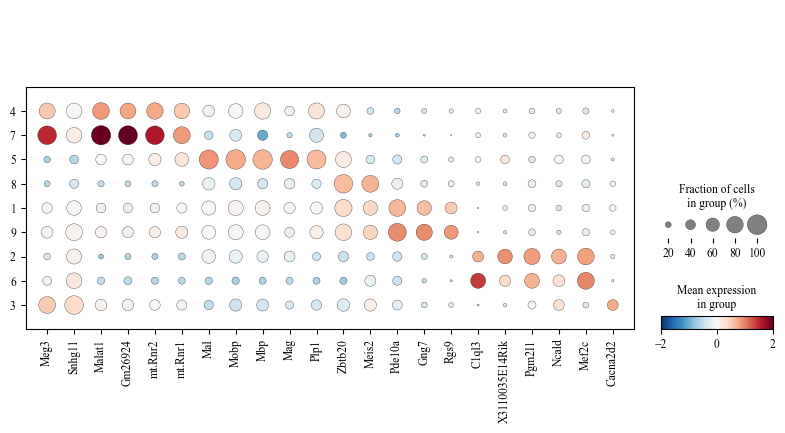

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Times New Roman"]
sc.pp.normalize_total(adata, target_sum=1e4)  
#sc.pp.log1p(adata)  


#sc.pp.highly_variable_genes(adata1, min_mean=0.0125, max_mean=3, min_disp=0.5)
#sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
#adata = adata[:, adata.var.highly_variable]


sc.tl.rank_genes_groups(adata, 'mclust', method='t-test')

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

markers = []
for group in groups:
    markers.extend(result['names'][group][:5])
adata1 = adata[adata.obs['batch'] == '0']

sc.pp.log1p(adata1)
sc.pp.scale(adata1)
custom_order_names = [4,7,5,8,1,9,2,6,3]
adata1.obs['mclust'] = adata1.obs['mclust'].cat.set_categories(custom_order_names)


#sc.pl.DotPlot(adata1, markers, 'mclust',cmap='RdBu_r',vmin=-2,vmax=2, ).show()


markers=['Meg3','Snhg11','Malat1', 'Gm26924', 'mt.Rnr2',  'mt.Rnr1','Mal', 'Mobp', 'Mbp', 'Mag', 'Plp1' ,'Zbtb20','Meis2','Pde10a','Gng7','Rgs9','C1ql3','X3110035E14Rik','Pgm2l1','Ncald','Mef2c','Cacna2d2', ]

sc.pl.DotPlot(adata1, markers, 'mclust', cmap='RdBu_r', vmin=-2, vmax=2).savefig('qipaotu_P21.pdf')#.show()

adata2 = adata[adata.obs['batch'] == '1']

sc.pp.log1p(adata2)
sc.pp.scale(adata2)
adata2.obs['mclust'] = adata2.obs['mclust'].cat.set_categories(custom_order_names)

sc.pl.DotPlot(adata2, markers, 'mclust',cmap='RdBu_r',vmin=-2,vmax=2 ).savefig('qipaotu_P22.pdf')#.show()



In [ ]:
import numpy as np
import scanpy as sc
import pandas as pd
import torch
import anndata as ad
from SPAIR.utils import lsi
from train_integrate import train_integration
# 读取数据
adata_rna1 =sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice3/s3_adata_rna.h5ad') 
adata_1 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice3/s3_adata_atac.h5ad')
adata_rna2 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice1/s1_adata_rna.h5ad')
adata_2 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice1/s1_adata_atac.h5ad')
adata_3 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/adata_ADTp22.h5ad')
print (adata_1)
print(adata_2)



AnnData object with n_obs × n_vars = 9215 × 161514
    obs: 'src'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 2372 × 161514
    obs: 'src'
    obsm: 'spatial'


In [2]:
adata_list=[adata_1,adata_1]
print(adata_list)

adata_concat=ad.concat(adata_list, label='batch')

[AnnData object with n_obs × n_vars = 9215 × 161514
    obs: 'src'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 9215 × 161514
    obs: 'src'
    obsm: 'spatial']


In [2]:
adata1=lsi(adata_1)
adata2=lsi(adata_2)


In [2]:
adata3=lsi(adata_3)

In [3]:
adata3=ad.AnnData(X=adata_3.obsm['X_lsi'])
adata3.obsm['spatial']=adata_3.obsm['spatial']

In [4]:
adata_list=[adata3,adata3]
print(adata_list)

adata_concat=ad.concat(adata_list, label='batch')

[AnnData object with n_obs × n_vars = 9215 × 49
    obsm: 'spatial', AnnData object with n_obs × n_vars = 9215 × 49
    obsm: 'spatial']


In [3]:
adata1=ad.AnnData(X=adata_1.obsm['X_lsi'])
adata1.obsm['spatial']=adata_1.obsm['spatial']
adata2=ad.AnnData(X=adata_2.obsm['X_lsi'])
adata2.obsm['spatial']=adata_2.obsm['spatial']



#an

adata_list=[adata1,adata1]
print(adata_list)

adata_concat=ad.concat(adata_list, label='batch')


[AnnData object with n_obs × n_vars = 9215 × 49
    obsm: 'spatial', AnnData object with n_obs × n_vars = 9215 × 49
    obsm: 'spatial']


In [5]:
adatas = train_integration(adata=adata_concat, epochs=400,radius=2)

3
[[   0  165]
 [   0 8180]
 [   0 9214]
 ...
 [9214 8258]
 [9214 7250]
 [9214 8259]]
>>> INFO: Generate 117889 edges, 11.793 edges per spot.(0.546s)
3
[[   0  165]
 [   0 8180]
 [   0 9214]
 ...
 [9214 8258]
 [9214 7250]
 [9214 8259]]
>>> INFO: Generate 117889 edges, 11.793 edges per spot.(0.218s)
>>> INFO: Finish generate precluster embedding(0.345s)!
[{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82

  0%|          | 0/400 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 616085 mnn node pairs(1.462s)!


 25%|██▌       | 100/400 [03:23<10:29,  2.10s/it]

>>> INFO: Finish finding mmn pairs, find 561091 mnn node pairs(1.311s)!


 50%|█████     | 200/400 [06:57<06:58,  2.09s/it]

>>> INFO: Finish finding mmn pairs, find 584059 mnn node pairs(1.317s)!


 75%|███████▌  | 300/400 [10:29<03:29,  2.09s/it]

>>> INFO: Finish finding mmn pairs, find 587049 mnn node pairs(1.313s)!


100%|██████████| 400/400 [14:00<00:00,  2.10s/it]


In [6]:
import st_datasets as stds
adatas = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=9)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [8]:
adatas.write('mousebrain_P2122atac_orign.h5ad', compression='gzip')

In [9]:
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import torch
import random

import anndata

import numpy as np
import scanpy as sc
import networkx as nx
import torch.nn as nn
adata1 = sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P2122RNA.h5ad')
adata2 = sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P2122atac_orign.h5ad')


In [10]:
from pyWNN import pyWNN

In [11]:
adata1

AnnData object with n_obs × n_vars = 11587 × 18107
    obs: 'src', 'batch', 'mclust'
    obsm: 'embedding', 'spatial'

In [12]:
adata1.obsm["embedding"].shape

(11587, 30)

In [13]:
adata2.obsm["embedding"].shape

(11587, 30)

In [14]:
adata1.obsm["embedding"]

array([[ 1.2627559 , -3.9444442 , -3.1347923 , ..., -6.666695  ,
        -4.1437387 , -1.2148261 ],
       [ 1.7107615 , -3.2878366 , -2.4922838 , ..., -6.7663307 ,
        -5.6766195 , -0.07744464],
       [ 1.5893569 , -3.1724482 , -2.2398179 , ..., -7.05299   ,
        -5.5540757 , -0.18116422],
       ...,
       [ 0.5266577 , -2.8069441 , -1.0857676 , ..., -7.1802325 ,
        -4.6882896 , -2.1339028 ],
       [ 0.40247464, -2.9158063 , -0.4950835 , ..., -7.3693953 ,
        -4.3549232 , -2.4044378 ],
       [ 0.61550474, -3.1048663 , -0.63875824, ..., -7.088818  ,
        -4.205248  , -2.1064258 ]], dtype=float32)

In [15]:
adata1.obsm['embeddingRNA']=adata2.obsm['embedding']

In [16]:
WNNobj = pyWNN(adata1, reps=['embedding', 'embeddingRNA'], npcs=[30,30], n_neighbors=20, seed=14)

Computing KNN distance matrices using default Scanpy implementation


In [17]:
adata = WNNobj.compute_wnn(adata1)

Computing modality weights
Computing weighted distances for union of 200 nearest neighbors between modalities
0 out of 11587 0.00 seconds elapsed
2000 out of 11587 5.70 seconds elapsed
4000 out of 11587 11.42 seconds elapsed
6000 out of 11587 17.19 seconds elapsed
8000 out of 11587 22.89 seconds elapsed
10000 out of 11587 28.65 seconds elapsed
Selecting top K neighbors


In [18]:
adata

AnnData object with n_obs × n_vars = 11587 × 18107
    obs: 'src', 'batch', 'mclust'
    uns: 'WNN'
    obsm: 'embedding', 'spatial', 'embeddingRNA', 'Weights', 'embedding_norm', 'embeddingRNA_norm'
    obsp: 'WNN', 'WNN_distance'

In [19]:
ww=adata.obsm['Weights']
ww = ww.astype(np.float32)
ww

array([[0.6128378 , 0.3871622 ],
       [0.5507682 , 0.44923183],
       [0.57243097, 0.42756903],
       ...,
       [0.4059489 , 0.5940511 ],
       [0.50119424, 0.49880576],
       [0.53497463, 0.46502534]], dtype=float32)

In [20]:
w1=ww[:,0]
w1.reshape(-1,1)
w1

array([0.6128378 , 0.5507682 , 0.57243097, ..., 0.4059489 , 0.50119424,
       0.53497463], dtype=float32)

In [21]:
x1=adata.obsm['embedding'].T*w1
x1


array([[ 0.7738645 ,  0.942233  ,  0.90979713, ...,  0.21379612,
         0.20171797,  0.32927942],
       [-2.4173045 , -1.8108358 , -1.8160076 , ..., -1.139476  ,
        -1.4613854 , -1.6610247 ],
       [-1.9211192 , -1.3726707 , -1.2821411 , ..., -0.4407662 ,
        -0.248133  , -0.34171945],
       ...,
       [-4.0856028 , -3.7266798 , -4.0373497 , ..., -2.9148076 ,
        -3.6934984 , -3.792338  ],
       [-2.5394397 , -3.1265016 , -3.1793249 , ..., -1.9032061 ,
        -2.1826625 , -2.249701  ],
       [-0.74449134, -0.04265404, -0.10370401, ..., -0.8662555 ,
        -1.2050904 , -1.1268843 ]], dtype=float32)

In [22]:
w2=ww[:,1]
w2.reshape(-1,1)
w2

array([0.3871622 , 0.44923183, 0.42756903, ..., 0.5940511 , 0.49880576,
       0.46502534], dtype=float32)

In [23]:
x2=adata.obsm['embeddingRNA'].T*w2
x2

array([[ 0.14044745, -0.07204847, -0.20426816, ...,  0.02218964,
        -0.01909543,  0.13055713],
       [-0.04332285,  0.04109091,  0.21542224, ..., -0.15690675,
        -0.12518865, -0.24036638],
       [ 0.0396054 , -0.06954548,  0.10859879, ..., -0.3032225 ,
        -0.17669041, -0.04767352],
       ...,
       [-0.01268805, -0.09241876, -0.08460008, ..., -0.48074746,
        -0.45208898, -0.3661573 ],
       [ 0.32493994, -0.2652766 ,  0.00949529, ..., -0.389253  ,
        -0.31823087, -0.178556  ],
       [-0.02343996,  0.28388375,  0.26659015, ...,  0.09882782,
         0.21760443, -0.09358048]], dtype=float32)

In [24]:
x=x1+x2
x

array([[ 0.91431195,  0.87018454,  0.705529  , ...,  0.23598577,
         0.18262254,  0.45983654],
       [-2.4606273 , -1.7697449 , -1.6005853 , ..., -1.2963827 ,
        -1.5865741 , -1.901391  ],
       [-1.8815138 , -1.4422162 , -1.1735423 , ..., -0.7439887 ,
        -0.4248234 , -0.38939297],
       ...,
       [-4.098291  , -3.8190985 , -4.1219497 , ..., -3.395555  ,
        -4.1455874 , -4.158495  ],
       [-2.2144997 , -3.3917782 , -3.1698296 , ..., -2.292459  ,
        -2.5008934 , -2.428257  ],
       [-0.7679313 ,  0.24122971,  0.16288614, ..., -0.7674277 ,
        -0.987486  , -1.2204648 ]], dtype=float32)

In [25]:
adata.obsm['embeddingcom']=x.T

In [26]:
adata.obsm['embeddingcom']

array([[ 0.91431195, -2.4606273 , -1.8815138 , ..., -4.098291  ,
        -2.2144997 , -0.7679313 ],
       [ 0.87018454, -1.7697449 , -1.4422162 , ..., -3.8190985 ,
        -3.3917782 ,  0.24122971],
       [ 0.705529  , -1.6005853 , -1.1735423 , ..., -4.1219497 ,
        -3.1698296 ,  0.16288614],
       ...,
       [ 0.23598577, -1.2963827 , -0.7439887 , ..., -3.395555  ,
        -2.292459  , -0.7674277 ],
       [ 0.18262254, -1.5865741 , -0.4248234 , ..., -4.1455874 ,
        -2.5008934 , -0.987486  ],
       [ 0.45983654, -1.901391  , -0.38939297, ..., -4.158495  ,
        -2.428257  , -1.2204648 ]], dtype=float32)

In [27]:
import st_datasets as stds
adata = stds.cl.mclust_R(adata, used_obsm='embeddingcom', num_cluster=9)

fitting ...
  |======================================================================| 100%


In [29]:
adata.write('mousebrain_P21_P22_RNA_atac_orign.h5ad', compression='gzip')

In [4]:
import scanpy as sc
adata=sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P21_P22_RNA_atac_orign.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 11587 × 18107
    obs: 'src', 'batch', 'mclust'
    uns: 'WNN'
    obsm: 'Weights', 'embedding', 'embeddingRNA', 'embeddingRNA_norm', 'embedding_norm', 'embeddingcom', 'spatial'
    obsp: 'WNN', 'WNN_distance'

In [6]:
adata1 = adata[adata.obs['batch'] == '0']
adata2 = adata[adata.obs['batch'] == '1']

In [7]:
adata1

View of AnnData object with n_obs × n_vars = 9215 × 18107
    obs: 'src', 'batch', 'mclust'
    uns: 'WNN'
    obsm: 'Weights', 'embedding', 'embeddingRNA', 'embeddingRNA_norm', 'embedding_norm', 'embeddingcom', 'spatial'
    obsp: 'WNN', 'WNN_distance'

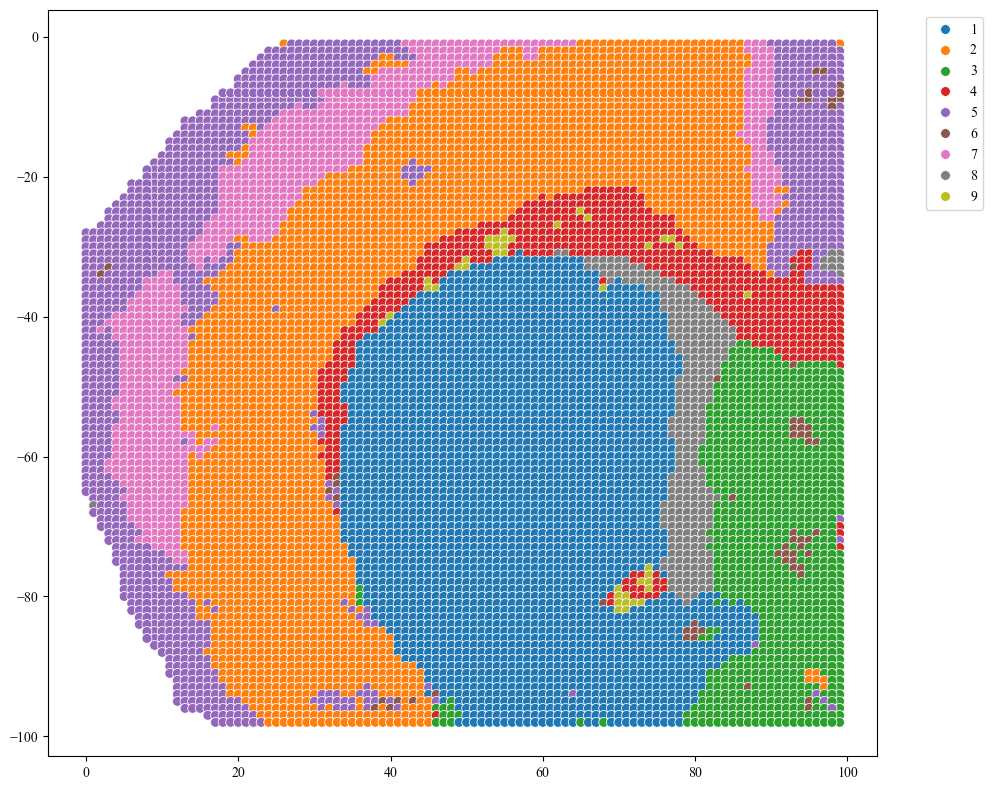

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns


spatial_coords = adata1.obsm['spatial']
    
   
cluster_labels = adata1.obs['mclust']
    
   
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=cluster_labels,
        
    s=50,               
    alpha=1           
)
    
  
    
    
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
    
    
plt.tight_layout()
plt.savefig('P22zhenghe_ours.pdf')
plt.show()

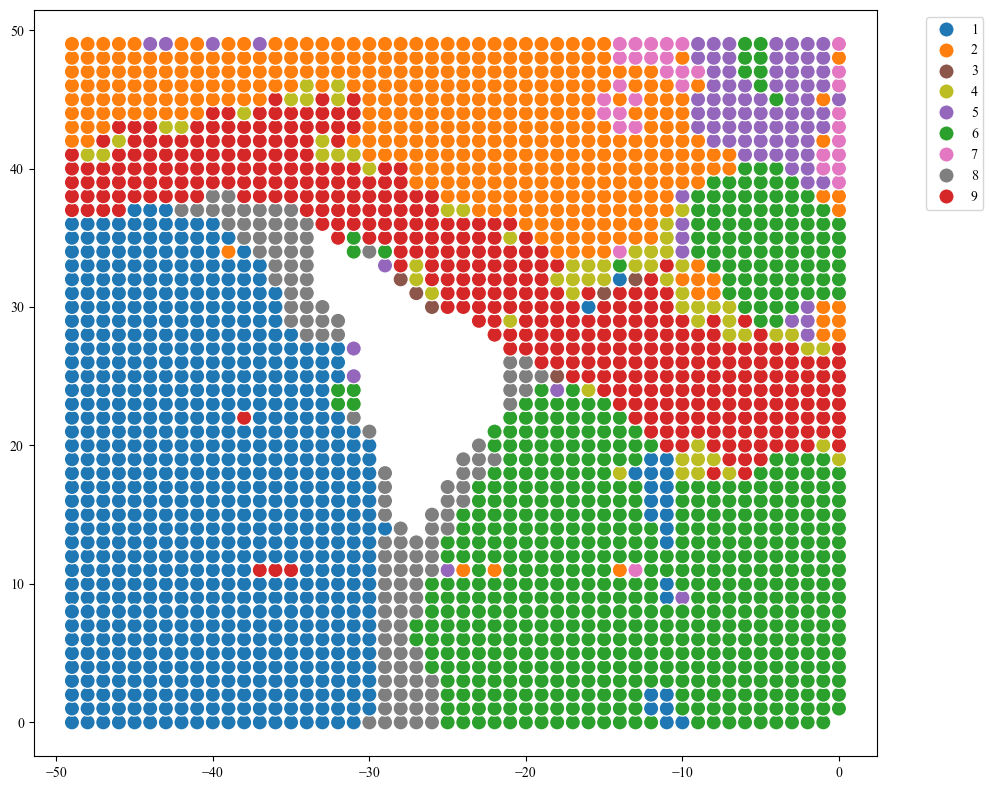

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns


spatial_coords = adata2.obsm['spatial']
    

cluster_labels = adata2.obs['mclust']



plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=cluster_labels,
    
    s=120,                
    alpha=1               
)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.savefig('P21zhenghe_ours.pdf')
plt.show()

In [29]:
adata

AnnData object with n_obs × n_vars = 9215 × 15867
    obs: 'RNA_clusters', 'batch', 'mclust'
    uns: 'WNN'
    obsm: 'embedding', 'spatial', 'embeddingRNA', 'Weights', 'embedding_norm', 'embeddingRNA_norm', 'embeddingcom'
    obsp: 'WNN', 'WNN_distance'

d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


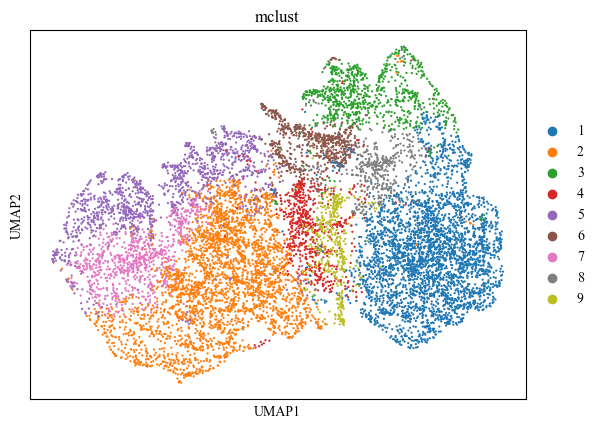

d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\Anaconda\envs\cast\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


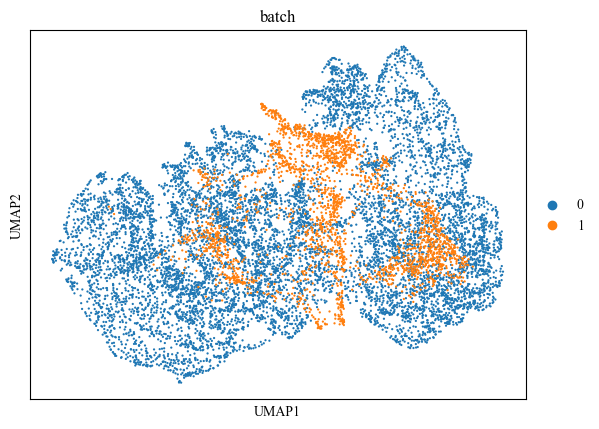

In [ ]:

sc.pp.neighbors(adata, use_rep='embeddingcom')
sc.tl.umap(adata)

    
sc.pl.umap(adata, color=['mclust'], title="mclust",save='UMAP_P21P22_mclust')
sc.pl.umap(adata, color=['batch'], title="batch",save='UMAP_P21P22_batch')

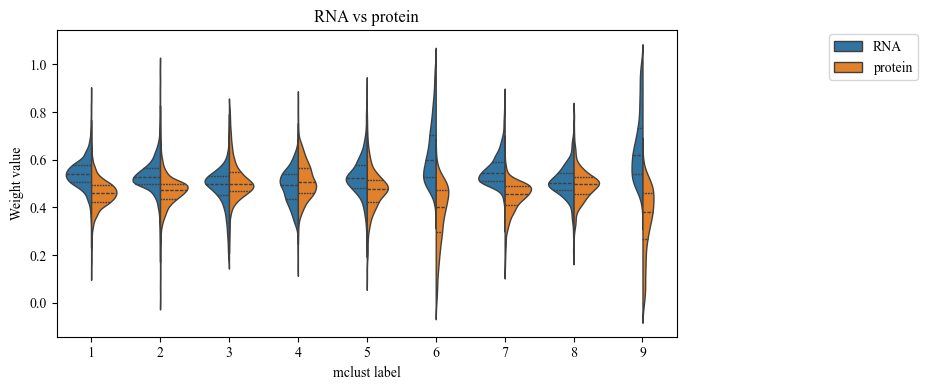

In [24]:
# plotting modality weight values.
import pandas as pd
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,4)
df = pd.DataFrame(columns=['RNA', 'protein', 'label'])
df['RNA'], df['protein'] = adata.obsm['Weights'][:, 0], adata.obsm['Weights'][:, 1]
df['label'] = adata.obs['mclust'].values
df = df.set_index('label').stack().reset_index()
df.columns = ['mclust', 'Modality', 'Weight value']
ax = sns.violinplot(data=df, x='mclust', y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1, )
ax.set_title('RNA vs protein')
ax.set_xlabel('mclust label')
ax.legend(bbox_to_anchor=(1.4, 1.01), loc='upper right')

plt.tight_layout(w_pad=0.05)
plt.savefig('P21P22weight.pdf')
#plt.show()

In [138]:
sc.pp.neighbors(adata2, use_rep='embeddingRNA',n_neighbors=20, n_pcs=30)

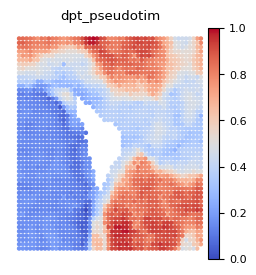

In [147]:

import matplotlib
import matplotlib.pyplot as plt
# Calculating pseudo-times
adata2.uns['iroot'] = np.flatnonzero(adata2.obs["mclust"] == 1)[2]
sc.tl.diffmap(adata2)
sc.tl.dpt(adata2)
pSM_values_cosmos = adata2.obs['dpt_pseudotime'].to_numpy()

# Ploting figures
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(3,3))
sz = 10
x = np.array(adata2.obsm['spatial'][:,0])
y = np.array(adata2.obsm['spatial'][:,1])
ax_temp = axes
im = ax_temp.scatter(x, y, s=20, c=pSM_values_cosmos, marker='.', cmap='coolwarm',alpha = 1,vmin=0, vmax=1)
ax_temp.axis('off')
ax_temp.set_title('dpt_pseudotim')
fig.colorbar(im, ax = ax_temp,orientation="vertical", pad=-0.01)
plt.savefig("p21psm.pdf")

In [142]:
sc.pp.neighbors(adata1,use_rep='embeddingRNA', n_neighbors=20, n_pcs=30)

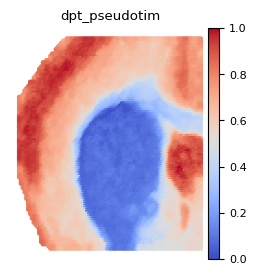

In [148]:

import matplotlib
import matplotlib.pyplot as plt
# Calculating pseudo-times
adata1.uns['iroot'] = np.flatnonzero(adata1.obs["mclust"] ==1)[2]
sc.tl.diffmap(adata1)
sc.tl.dpt(adata1)
pSM_values_cosmos = adata1.obs['dpt_pseudotime'].to_numpy()

# Ploting figures
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(3,3))
sz = 10
x = np.array(adata1.obsm['spatial'][:,0])
y = np.array(adata1.obsm['spatial'][:,1])
ax_temp = axes
im = ax_temp.scatter(x, y, s=20, c=pSM_values_cosmos, marker='.', cmap='coolwarm',alpha = 1,vmin=0, vmax=1)
ax_temp.axis('off')
ax_temp.set_title('dpt_pseudotim')
fig.colorbar(im, ax = ax_temp,orientation="vertical", pad=-0.01)
plt.savefig("p22psm.pdf")

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('D:/biancheng/stMSA-master/mousebrain_P21_P22_RNA_atac_orign1.h5ad')
adata_list = []
for i in range(2):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1451, 2)
>>> INFO: src coordination shape: (994, 2)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
>>> INFO: current distance: 1.158520578885963


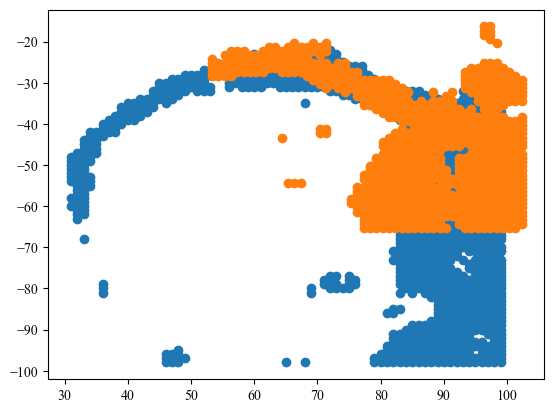

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 1.00000000e+00, -6.74434415e-09,  1.02327586e+02],
        [ 6.74434422e-09,  1.00000000e+00, -6.53160074e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [2]:
dst_id = 0
pyramidal_label_id = [3,4]
src_id_list = list(range(0, 2))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-4,threshold=500)
M

[array([[99., 17., 18., ..., 96., 97., 98.],
       [-9., -9., -9., ..., -8., -8., -8.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.]]), array([[102.32758573,  93.32758573,  92.32758573, ...,  96.32758573,
         95.32758573,  94.32758573],
       [-56.31600742, -56.31600748, -56.31600749, ..., -57.31600746,
        -57.31600747, -57.31600747],
       [  1.        ,   1.        ,   1.        , ...,   1.        ,
          1.        ,   1.        ]])]
[array([6, 5, 5, ..., 5, 5, 5], dtype=int64), array([3, 3, 5, ..., 3, 3, 3], dtype=int64)]
0.3486706456863809


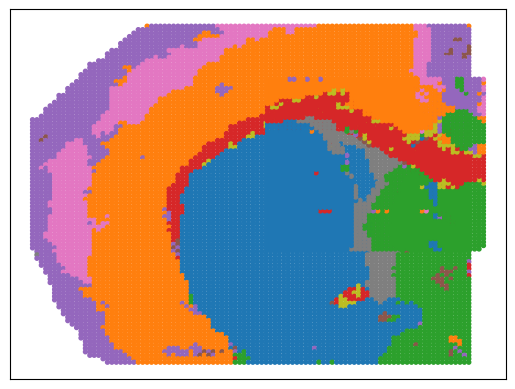

In [3]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['mclust'].to_numpy() for src_id in src_id_list]
print(coor_list)
print(label_list)

plotting(coor_list, label_list, save_path='P21P22_zhenghe.pdf',spot_size=8)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

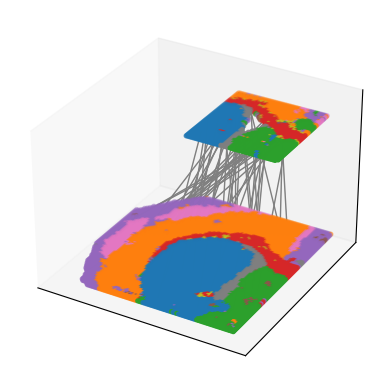

In [13]:
plotting(
    coor_list,
    label_list,
    save_path='P21P22_3D.pdf',
    dims='3d',
    
    spot_size=8,
    line_list=np.hstack([np.arange(src.shape[0]).reshape(-1, 1), order]).reshape(1, -1, 2)[:, np.random.randint(low=5, high=src.shape[0], size=50), :],
    
)